In [2]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
scipy.integrate.trapz = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
import PyMieScatt as Mie

In [3]:
size_x=2
size_y=2
size_z=2
cell_size=mp.Vector3(size_x,size_y,size_z)
sphere_radius = 0.25
sphere_refractive_index = 2
sphere_material = mp.Medium(index = sphere_refractive_index)

In [4]:
center_wl= 0.55
min_wl=0.4
max_wl=0.7
center_fq = 1/center_wl
freq_BW = 1/min_wl - 1/max_wl

In [5]:
source_pos = - size_y * 0.5 +0.3
gaussian_pulse = mp.GaussianSource(frequency = center_fq, fwidth = 2* freq_BW, is_integrated = True) 

In [6]:
source= [mp.Source(gaussian_pulse,
                    component = mp.Ez,
                    center = mp.Vector3(0,source_pos),
                   size= mp.Vector3(size_x,0,size_z))]

In [7]:
step_size = min([sphere_radius, min_wl])/10
resolution= 1/step_size
pmls= [mp.PML(thickness=10*step_size)]

In [8]:
sim = mp.Simulation(resolution = resolution,
                    cell_size = cell_size,
                    sources = source,
                    boundary_layers = pmls,
                    geometry = [])


# # add monitors
wavelengths = np.linspace(min_wl, max_wl, 41) # wavelengths for monitors
frequencies = 1.0 / wavelengths

# # Domain DFT monitor
dft_freqs = [1./min_wl, center_fq, 1./max_wl]
dft_fields = sim.add_dft_fields([mp.Ez],
                                dft_freqs,
                                center = mp.Vector3(),
                                size = mp.Vector3(size_x,size_y))

# Flux box monitors
box_size = sphere_radius * 4
box_mx = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = -box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_px = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_my = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=-box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_py = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_mz = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=-box_size/2),size=mp.Vector3(x = box_size, y = box_size)))
box_pz = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=box_size/2),size=mp.Vector3(x = box_size, y = box_size)))


# visualize the simulation domain
sim.plot2D(output_plane = mp.Volume(center = mp.Vector3(), size = mp.Vector3(size_x,size_y)))
plt.savefig("simXY_empty.png")
plt.close()


sim.plot2D(output_plane = mp.Volume(center = mp.Vector3(), size = mp.Vector3(size_x,0,size_z)))
plt.savefig("simXZ_empty.png")
plt.close()

# run the empty-domain simulation
# sim.run(until_after_sources = 10)
sim.run(until_after_sources = mp.stop_when_fields_decayed(10, mp.Ez, mp.Vector3(0,box_size/2,0), 1e-4))


-----------
Initializing structure...
time for choose_chunkdivision = 0.0006001 s
Working in 3D dimensions.
Computational cell is 2 x 2 x 2 with resolution 40
time for set_epsilon = 1.64681 s
-----------
on time step 50 (time=0.625), 0.0804124 s/step
on time step 195 (time=2.4375), 0.0277192 s/step
on time step 336 (time=4.2), 0.0283897 s/step
on time step 456 (time=5.7), 0.0334666 s/step
on time step 583 (time=7.2875), 0.0315598 s/step
on time step 716 (time=8.95), 0.0302152 s/step
field decay(t = 10.012500000000001): 0.25603068965183867 / 0.25603068965183867 = 1.0
on time step 846 (time=10.575), 0.0308214 s/step
on time step 948 (time=11.85), 0.0393693 s/step
on time step 1097 (time=13.7125), 0.0268867 s/step
on time step 1243 (time=15.5375), 0.0274209 s/step
on time step 1392 (time=17.4), 0.0269528 s/step
on time step 1542 (time=19.275), 0.0267799 s/step
field decay(t = 20.012500000000003): 1.894628531274475e-12 / 0.25603068965183867 = 7.400005576873893e-12
run 0 finished at t = 20.

In [10]:
for f in range(len(dft_freqs)):
    Ez_f = sim.get_dft_array(dft_fields,mp.Ez,f)
    plt.imshow(np.real(Ez_f),extent = [-size_y/2, size_y/2, -size_x/2, size_x/2])
    plt.savefig(f"Ez_f_{1./dft_freqs[f]}.png")
    plt.close()

# Store flux monitor data for empty simulation
box_mx_data_empty = sim.get_flux_data(box_mx)
box_px_data_empty = sim.get_flux_data(box_px)
box_my_data_empty = sim.get_flux_data(box_my)
box_py_data_empty = sim.get_flux_data(box_py)
box_mz_data_empty = sim.get_flux_data(box_mz)
box_pz_data_empty = sim.get_flux_data(box_pz)

incident_intensity = np.array(mp.get_fluxes(box_my)) / (box_size ** 2) # calculate incident intensity for normalization later

plt.plot(wavelengths,incident_intensity)
plt.savefig('Inc_Intensity.png')
plt.close()
sim.reset_meep()


In [11]:
geometry = [mp.Sphere(material = sphere_material, center = mp.Vector3(), radius = sphere_radius)]
sim = mp.Simulation(resolution = resolution,
                    cell_size = cell_size,
                    sources = source,
                    boundary_layers = pmls,
                    geometry = geometry,
                    Courant = 0.3)


In [15]:
# DFT Monitor
dft_freqs = [1./min_wl, center_fq, 1./max_wl]
dft_fields = sim.add_dft_fields([mp.Ez],
                                dft_freqs,
                                center = mp.Vector3(),
                                size = mp.Vector3(size_x,size_y))

# Scattering flux monitors
box_mx = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = -box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_px = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_my = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=-box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_py = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_mz = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=-box_size/2),size=mp.Vector3(x = box_size, y = box_size)))
box_pz = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=box_size/2),size=mp.Vector3(x = box_size, y = box_size)))

# Absorption flux monitors
box_mx_abs = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = -box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_px_abs = sim.add_flux(frequencies, mp.FluxRegion(center = mp.Vector3(x = box_size / 2), size = mp.Vector3(0,box_size,box_size)))
box_my_abs = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=-box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_py_abs = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(y=box_size/2),size=mp.Vector3(x = box_size, z = box_size)))
box_mz_abs = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=-box_size/2),size=mp.Vector3(x = box_size, y = box_size)))
box_pz_abs = sim.add_flux(frequencies,mp.FluxRegion(center=mp.Vector3(z=box_size/2),size=mp.Vector3(x = box_size, y = box_size)))


-----------
Initializing structure...
time for choose_chunkdivision = 0.00482988 s
Working in 3D dimensions.
Computational cell is 2 x 2 x 2 with resolution 40
     sphere, center = (0,0,0)
          radius 0.25
          dielectric constant epsilon diagonal = (4,4,4)
time for set_epsilon = 7.34555 s
-----------


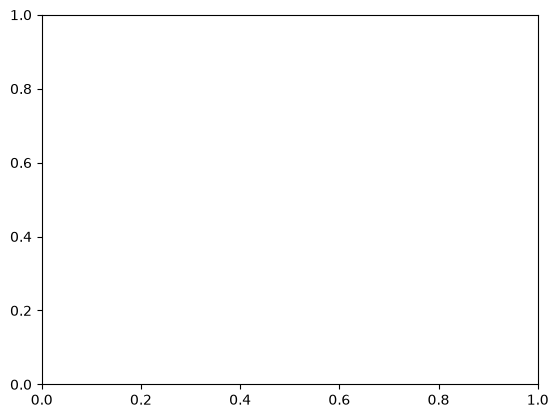

In [16]:
# Load empty-domain simulation data into scattering monitor
sim.load_minus_flux_data(box_mx, box_mx_data_empty)
sim.load_minus_flux_data(box_px, box_px_data_empty)
sim.load_minus_flux_data(box_my, box_my_data_empty)
sim.load_minus_flux_data(box_py, box_py_data_empty)
sim.load_minus_flux_data(box_mz, box_mz_data_empty)
sim.load_minus_flux_data(box_pz, box_pz_data_empty)

# add movie monitors
animate = mp.Animate2D(fields=mp.Ez,
                       normalize = True,
                       # field_parameters={'alpha':0.8, 'cmap':'RdBu', 'interpolation':'none'},
                       # boundary_parameters={'hatch':'o', 'linewidth':1.5, 'facecolor':'y', 'edgecolor':'b', 'alpha':0.3},
                       output_plane = mp.Volume(center = mp.Vector3(), size = mp.Vector3(size_x,size_y)))


In [18]:
sim.plot2D(output_plane = mp.Volume(center = mp.Vector3(), size = mp.Vector3(size_x,size_y)))
plt.savefig("simXY.png")
plt.close()

sim.plot2D(output_plane = mp.Volume(center = mp.Vector3(), size = mp.Vector3(size_x,0,size_z)))
plt.savefig("simXZ.png")
plt.close()

# Run simulation with scatterer + movie monitor
sim.run(mp.at_every(0.1,animate),until_after_sources = mp.stop_when_fields_decayed(10, mp.Ez, mp.Vector3(0,box_size/2,0), 1e-4))

# Create movie - requires ffmpeg
animate.to_mp4(fps = 10, filename = 'Nanosphere_Simulation.mp4')
plt.close()


     sphere, center = (0,0,0)
          radius 0.25
          dielectric constant epsilon diagonal = (4,4,4)
     sphere, center = (0,0,0)
          radius 0.25
          dielectric constant epsilon diagonal = (4,4,4)
     sphere, center = (0,0,0)
          radius 0.25
          dielectric constant epsilon diagonal = (4,4,4)
on time step 46 (time=0.345), 0.0871859 s/step
on time step 171 (time=1.2825), 0.0321269 s/step
on time step 315 (time=2.3625), 0.0278973 s/step
on time step 453 (time=3.3975), 0.0291193 s/step
on time step 575 (time=4.3125), 0.0328841 s/step
on time step 705 (time=5.2875), 0.0308098 s/step
on time step 835 (time=6.2625), 0.0309263 s/step
on time step 959 (time=7.1925), 0.0324684 s/step
on time step 1100 (time=8.25), 0.0284144 s/step
on time step 1231 (time=9.2325), 0.030683 s/step
field decay(t = 10.004999999999999): 0.10479446653681684 / 0.10479446653681684 = 1.0
on time step 1352 (time=10.14), 0.0330924 s/step
on time step 1489 (time=11.1675), 0.0292007 s/step
o

In [19]:
# Plot Fourier Transform fields
for f in range(len(dft_freqs)):
    Ez_f = sim.get_dft_array(dft_fields,mp.Ez,f)
    plt.imshow(np.real(Ez_f),extent = [-size_y/2, size_y/2, -size_x/2, size_x/2])
    plt.savefig(f"Ez_f_{1./dft_freqs[f]}.png")
    plt.close()

# get scattering fluxes
box_mx_flux = np.array(mp.get_fluxes(box_mx))
box_px_flux = np.array(mp.get_fluxes(box_px))
box_my_flux = np.array(mp.get_fluxes(box_my))
box_py_flux = np.array(mp.get_fluxes(box_py))
box_pz_flux = np.array(mp.get_fluxes(box_pz))
box_mz_flux = np.array(mp.get_fluxes(box_mz))
# get absorption fluxes
box_mx_flux_abs = np.array(mp.get_fluxes(box_mx_abs))
box_px_flux_abs = np.array(mp.get_fluxes(box_px_abs))
box_my_flux_abs = np.array(mp.get_fluxes(box_my_abs))
box_py_flux_abs = np.array(mp.get_fluxes(box_py_abs))
box_pz_flux_abs = np.array(mp.get_fluxes(box_pz_abs))
box_mz_flux_abs = np.array(mp.get_fluxes(box_mz_abs))

In [ ]:
# Calculate scattering cross-section data and compare with Mie theory
scatt_flux = -box_mx_flux + box_px_flux -box_my_flux + box_py_flux -box_mz_flux + box_pz_flux
abs_flux = -box_mx_flux_abs + box_px_flux_abs -box_my_flux_abs + box_py_flux_abs -box_mz_flux_abs + box_pz_flux_abs

scatt_cross_section = scatt_flux / incident_intensity
abs_cross_section = -abs_flux / incident_intensity

mie_wavelengths = np.linspace(min_wavelength,max_wavelength,100)
permittivities = np.array([Ag.epsilon(1./wl) for wl in mie_wavelengths])
sphere_refractive_index = np.sqrt(permittivities)[:,0,0]
print(sphere_refractive_index)

Q_sca, Q_abs, _ = Mie_Solver(Sphere_Radius = sphere_radius,
                                    Sphere_refractive_index = sphere_refractive_index,
                                    Wavelengths = mie_wavelengths)


plt.plot(wavelengths,scatt_cross_section / (np.pi * sphere_radius ** 2),'x',color = 'red')
plt.plot(mie_wavelengths,Q_sca,'blue')
plt.savefig("scattering_spectrum.png")
plt.close()

plt.plot(wavelengths,abs_cross_section / (np.pi * sphere_radius ** 2),'x',color = 'red')
plt.plot(mie_wavelengths,Q_abs,'blue')
plt.savefig("absorption_spectrum.png")
plt.close()